<a href="https://colab.research.google.com/github/SIVASURYAPK/Academic-Performance-Predictor/blob/main/Student_Grades_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading Gaming & Academic dataset...
Training the Decision Tree Regressor...

--- REGRESSION METRICS ---
Mean Absolute Error (MAE): 6.96 grade points
Mean Squared Error (MSE):  79.53
R-Squared (R2):            0.8413



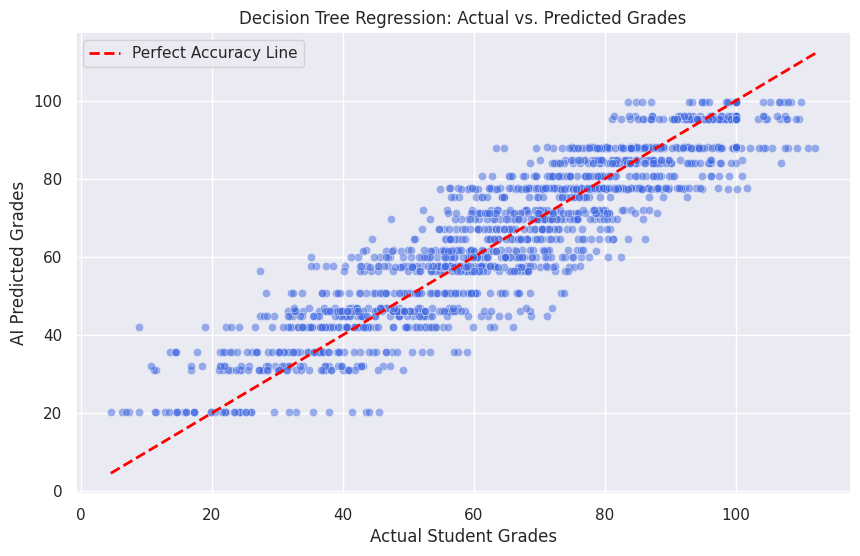

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="darkgrid")

# ==========================================
# PART 1: LOAD AND PREPARE DATA
# ==========================================
print("Loading Gaming & Academic dataset...")
df = pd.read_csv('/content/Gaming_Academic_Performance.csv')

# Quick clean-up (just in case there are anomalies)
df.dropna(subset=['study_hours', 'gaming_hours', 'sleep_hours', 'grades'], inplace=True)

# ==========================================
# PART 2: THE MACHINE LEARNING PIPELINE
# ==========================================
print("Training the Decision Tree Regressor...\n")

# 1. Isolate Features (X) and Target (y)
# We are using MULTIPLE features this time, which is a big step up from Week 2!
X = df[['study_hours', 'gaming_hours', 'sleep_hours']]
y = df['grades'] # Continuous target

# 2. Train/Test Split (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Model
# We limit the depth of the tree so it doesn't "overfit" and memorize the data
model = DecisionTreeRegressor(max_depth=5, random_state=42)
model.fit(X_train, y_train)

# 4. Make Predictions
y_pred = model.predict(X_test)

# ==========================================
# PART 3: THIRANEX EVALUATION METRICS
# ==========================================
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- REGRESSION METRICS ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} grade points")
print(f"Mean Squared Error (MSE):  {mse:.2f}")
print(f"R-Squared (R2):            {r2:.4f}\n")

# ==========================================
# PART 4: VISUALIZING THE PREDICTIONS
# ==========================================
plt.figure(figsize=(10, 6))
# Plotting Actual vs. Predicted values
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='royalblue')

# Drawing the "Perfect Prediction" line
max_val = max(y_test.max(), y_pred.max())
min_val = min(y_test.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Accuracy Line')

plt.title('Decision Tree Regression: Actual vs. Predicted Grades')
plt.xlabel('Actual Student Grades')
plt.ylabel('AI Predicted Grades')
plt.legend()
plt.show()